# Particle tracking

This example demonstrates forward particle tracking with a transient flow system.
The model represents a seepage scenario in which more permeable layers at higher
elevation start out dry, and gradually wet over the course of the simulation, as
the flow system receives water from boundary conditions. Particles are released
into the top layer, representing contaminants which will begin to migrate after
the water table reaches them.

We will first run the flow model as is, and demonstrate the DRAPE option's usage
with both MODPATH 7 and PRT, producing equivalent particle tracking results. Then
we will modify the flow model to use the Newton formulation, such that dry cells
remain active. PRT provides more flexible behavior in this circumstance than MP7.
We will demonstrate how to control particle behavior in dry conditions with PRT.

First, set up a time discretization with 3 stress periods: one steady-state, one
transient, and a final steady-state. The injection well will be active only in the
second period.

In [2]:
nper = 3
period_data = [
    (1, 1, 1.0),
    (300, 30, 1.1),
    (1000, 1, 1.0),
]

Set up a grid discretization: three 10m-thick layers below a 1600m top surface.

In [3]:
import numpy as np

nlay, nrow, ncol = 3, 20, 20
Lx, Ly = 100.0, 100.0
delr, delc = Lx / ncol, Ly / nrow
z_top = 1600.0
thickness = 10.0

z_bot = np.zeros((nlay, nrow, ncol))
for k in range(nlay):
    z_bot[k] = z_top - (k + 1) * thickness

Construct a simulation for the flow model.

In [4]:
from pathlib import Path
import flopy

example_name = "prt-a"
gwf_name = f"{example_name}-gwf"
base_ws = Path("models") / example_name
gwf_ws = base_ws / "gwf"
gwf_ws.mkdir(exist_ok=True, parents=True)

In [5]:
gwf_sim = flopy.mf6.MFSimulation(
    sim_name=gwf_name,
    exe_name="mf6",
    version="mf6",
    continue_=True,
    sim_ws=gwf_ws,
)

In [6]:
tdis = flopy.mf6.ModflowTdis(
    gwf_sim,
    time_units="days",
    nper=nper,
    perioddata=period_data,
)

In [7]:
gwf = flopy.mf6.ModflowGwf(
    gwf_sim,
    modelname=gwf_name,
    # newtonoptions="NEWTON",  # TODO uncomment after first pass
    save_flows=True,
)

In [8]:
dis = flopy.mf6.ModflowGwfdis(
    gwf,
    length_units="METERS",
    nlay=nlay,
    nrow=nrow,
    ncol=ncol,
    delr=delr,
    delc=delc,
    top=z_top,
    botm=z_bot,
)

Initial conditions begin fully saturated; the first steady state stress period
will cause the water table to drop before it begins to rise in the 2nd period.

In [9]:
ic = flopy.mf6.ModflowGwfic(gwf, strt=z_top)

The model grid's cells are convertible, with greater hydraulic conductivity in
the lateral than the vertical direction.

In [10]:
npf = flopy.mf6.ModflowGwfnpf(
    gwf,
    icelltype=1,
    k=0.5,
    k33=0.1,
    save_specific_discharge=True,
    save_saturation=True,
    save_flows=True,
)

Configure STO convertibility to match NPF and steady-state/transient options to match
the time discretization.

In [11]:
sto = flopy.mf6.ModflowGwfsto(
    gwf,
    iconvert=1,
    ss=0.0001,
    sy=0.1,
    steady_state={0: True, 2: True},
    transient={1: True},
    save_flows=True,
)

Constant-head boundaries establish a mild head gradient from upper-left to lower-right.

In [12]:
chd = flopy.mf6.ModflowGwfchd(
    gwf,
    stress_period_data={i: [
        (1, 0, 0, 1587.0),
        (1, nrow - 1, ncol - 1, 1582.0)
    ] for i in range(nper)},
    save_flows=True,
)

An injection well sits in layer 1 near the upper-left quadrant.
Particles are released from layer 0 (the top, initially dry layer)
in the five cells surrounding the well in plan view.

The injection well is active only in the transient period; pumping rate 100 m³/d.

In [13]:
well_lay, well_row, well_col = 1, nrow // 4, ncol // 4
wel = flopy.mf6.ModflowGwfwel(
    gwf,
    stress_period_data={i: [(well_lay, well_row, well_col, 100.0)] for i in range(1, nper)},
    save_flows=True,
)

Configure output control, enabling comprehensive head and budget reporting.

In [14]:
oc = flopy.mf6.ModflowGwfoc(
    gwf,
    budget_filerecord=f"{gwf_name}.cbb",
    head_filerecord=f"{gwf_name}.hds",
    saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")],
)

Set up the iterative model solution.

In [15]:
ims = flopy.mf6.ModflowIms(
    gwf_sim,
    complexity="MODERATE",
    outer_dvclose=1e-5,
    inner_dvclose=1e-6,
    pname=gwf_name,
)

In [16]:
# TODO: Comment out the block above and uncomment this one when Newton is enabled.

# flopy.mf6.ModflowIms(
#     gwf_sim,
#     print_option="SUMMARY",
#     outer_dvclose=1e-5,
#     outer_maximum=100,
#     under_relaxation="DBD",
#     under_relaxation_gamma=0.01,
#     under_relaxation_theta=0.7,
#     under_relaxation_kappa=0.01,
#     under_relaxation_momentum=0.0,
#     inner_maximum=100,
#     inner_dvclose=1e-6,
#     rcloserecord=0.1,
#     linear_acceleration="BICGSTAB",
#     relaxation_factor=0.99,
#     number_orthogonalizations=2,
#     reordering_method="NONE",
#     pname=gwf_name,
# )

Now write and run the flow simulation.

In [17]:
gwf_sim.write_simulation(silent=True)
gwf_sim.run_simulation(silent=False)

FloPy is using the following executable to run the model: ../../../../../.pixi/envs/default/bin/mf6
                               MODFLOW 6 EXTENDED
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                          VERSION 6.8.0.dev0+a6a49847
                               ***DEVELOP MODE***

        MODFLOW 6 compiled Jun  1 2026 15:48:17 with GCC version 15.2.0

This software is preliminary or provisional and is subject to 
revision. It is being provided to meet the need for timely best 
science. The software has not received final approval by the U.S. 
Geological Survey (USGS). No warranty, expressed or implied, is made 
by the USGS or the U.S. Government as to the functionality of the 
software and related material nor shall the fact of release 
constitute any such warranty. The software is provided on the 
condition that neither the USGS nor the U.S. Government shall be held 
liable for any damages resulting from the authorized or unauthorized 
use of the 

(True, [])

Load flow results, then plot heads in the middle layer at the end of each period.
By the end of the initial steady-state period the CHD boundaries have drained the
flow system so that the top layer is fully dry. By the end of the simulation, the
water table has risen such that the top layer is partially saturated.

In [18]:
hds = gwf.output.head()
hds_kper0 = hds.get_data(kstpkper=(0, 0))
hds_kper1 = hds.get_data(kstpkper=(0, 1))
hds_kper2 = hds.get_data(kstpkper=(0, 2))

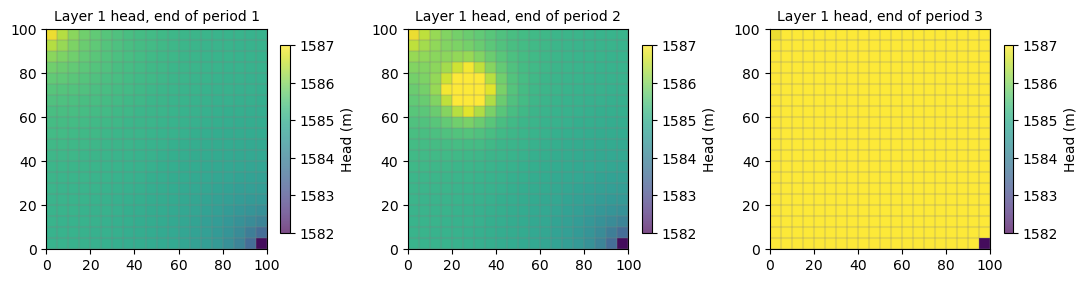

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(11, 5))
for ax, arr, title in [
    (axes[0], hds_kper0[1], "Layer 1 head, end of period 1"),
    (axes[1], hds_kper1[1], "Layer 1 head, end of period 2"),
    (axes[2], hds_kper2[1], "Layer 1 head, end of period 3"),
]:
    ax.set_aspect("equal")
    mm = flopy.plot.PlotMapView(gwf, ax=ax, layer=1)
    mm.plot_grid(alpha=0.2)
    mm.plot_bc("WEL", plotAll=True, color="red")
    mm.plot_bc("CHD", plotAll=True, color="steelblue")
    pc = mm.plot_array(arr, alpha=0.7, vmin=1582, vmax=1587)
    plt.colorbar(pc, ax=ax, shrink=0.4, label="Head (m)")
    ax.set_title(title, fontsize=10)
fig.tight_layout()
plt.show()

Confirm that the top layer is dry by checking that its cells have head < 1590 m.

In [20]:
dry_layer0 = (hds_kper0[0] < z_bot[0]).sum()
print(f"Dry cells in top layer after first stress period: {dry_layer0} of {nrow * ncol}")

Dry cells in top layer after first stress period: 400 of 400


We can now begin setting up the particle tracking models. We will release particles
from the top-layer cell directly above the middle-layer injection well and its
immediately adjacent neighbors.

Release locations are defined with flopy's MP7 release-template module,
then converted with a flopy utility to a format suitable for PRT. This
demonstrates a key step in migrating an MP7 model to PRT.

In [45]:
offsets = [(-1, 0, 0), (-1, -1, 0), (-1, 1, 0), (-1, 0, -1), (-1, 0, 1)]
release_cells = [
    (well_lay + dk, well_row + di, well_col + dj) for dk, di, dj in offsets
]
release_cells

[(0, 5, 5), (0, 4, 5), (0, 6, 5), (0, 5, 4), (0, 5, 6)]

Set up a cell template for MP7 template subdivision type 2.

In [46]:
mp7_cell_data = flopy.modpath.CellDataType(
    drape=1,
    rowcelldivisions=1,
    columncelldivisions=1,
    layercelldivisions=1
)

Set up a release region.

In [48]:
release_cells_T = np.array(release_cells).T
lrcregions = [[[
    min(release_cells_T[0]),
    min(release_cells_T[1]),
    min(release_cells_T[2]),
    max(release_cells_T[0]),
    max(release_cells_T[1]),
    max(release_cells_T[2])
]]]
lrcregions

[[[np.int64(0),
   np.int64(4),
   np.int64(4),
   np.int64(0),
   np.int64(6),
   np.int64(6)]]]

Now construct the MP7 model.

In [ ]:
mp7_particle_data = flopy.modpath.LRCParticleData(
    subdivisiondata=mp7_cell_data,
    lrcregions=lrcregions,
)
mp7_pg = flopy.modpath.ParticleGroupLRCTemplate(
    particlegroupname="PG1",
    particledata=mp7_particle_data,
    filename="pg1.sloc",
)

mp7_name = f"{example_name}-mp7"
mp7_ws = base_ws / "mp7"
mp7_ws.mkdir(exist_ok=True, parents=True)

mp7 = flopy.modpath.Modpath7(
    modelname=mp7_name,
    flowmodel=gwf,
    exe_name="mp7",
    model_ws=mp7_ws,
    budgetfilename=f"{gwf_name}.cbb",
    headfilename=f"{gwf_name}.hds",
)

porosity = 0.1
bas = flopy.modpath.Modpath7Bas(mp7, porosity=porosity)

mp7_sim = flopy.modpath.Modpath7Sim(
    mp7,
    simulationtype="combined",
    budgetoutputoption="summary",
    particlegroups=[mp7_pg],
)

Write and run the MP7 model.

In [50]:
mp7.write_input()
mp7.run_model(silent=False)

FloPy is using the following executable to run the model: ../../../../../.pixi/envs/default/bin/mp7

MODPATH Version 7.2.001   
Program compiled May 26 2026 17:12:29 with GFORTRAN compiler (ver. 12.5.0)      


Run particle tracking simulation ...
Processing Time Step     1 Period     1.  Time =  1.00000E+00  Steady-state flow                                                    
Processing Time Step     1 Period     2.  Time =  2.82377E+00  Transient flow                                                       
Processing Time Step     2 Period     2.  Time =  4.82993E+00  Transient flow                                                       
Processing Time Step     3 Period     2.  Time =  7.03669E+00  Transient flow                                                       
Processing Time Step     4 Period     2.  Time =  9.46414E+00  Transient flow                                                       
Processing Time Step     5 Period     2.  Time =  1.21343E+01  Transient flow          

(True, [])

Load and plot MP7 results.

In [51]:
import pandas as pd

mp7_pl_file = flopy.utils.PathlineFile(mp7_ws / f"{mp7_name}.mppth")
mp7_pls = pd.DataFrame(mp7_pl_file.get_destination_pathline_data(range(gwf.modelgrid.nnodes), to_recarray=True))

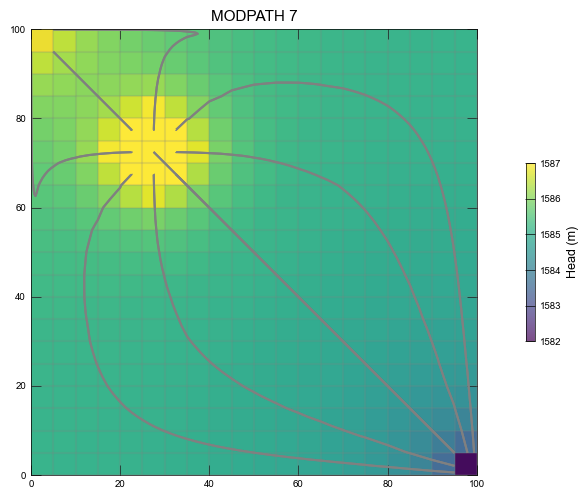

In [52]:
with flopy.plot.styles.USGSPlot():
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    ax.set_aspect("equal")
    mm = flopy.plot.PlotMapView(gwf, ax=ax, layer=1)
    mm.plot_grid(alpha=0.2)
    mm.plot_bc("WEL", plotAll=True, color="red")
    mm.plot_bc("CHD", plotAll=True, color="steelblue")
    pc = mm.plot_array(hds_kper1[1], alpha=0.7, vmin=1582, vmax=1587)
    mm.plot_pathline(mp7_pls)
    plt.colorbar(pc, ax=ax, shrink=0.4, label="Head (m)")
    ax.set_title("MODPATH 7", fontsize=11)
    # fig.suptitle("Without Newton: MP7 and PRT give equivalent results", fontsize=12)
    fig.tight_layout()
    plt.show()

Now construct an equivalent PRT model. Start by creating the simulation, time and grid discretization to match the flow model above, and a Model Input Package.

In [ ]:
prt_name = f"{example_name}-prt"
prt_ws = base_ws / "prt"
prt_ws.mkdir(exist_ok=True, parents=True)

prt_sim = flopy.mf6.MFSimulation(
    sim_name=prt_name,
    exe_name="mf6",
    version="mf6",
    continue_=True,
    sim_ws=prt_ws,
)

tdis = flopy.mf6.ModflowTdis(
    prt_sim,
    time_units="days",
    nper=nper,
    perioddata=period_data,
)

prt = flopy.mf6.ModflowPrt(
    prt_sim,
    modelname=prt_name,
    model_nam_file=f"{prt_name}.nam",
)

dis = flopy.mf6.ModflowPrtdis(
    prt,
    length_units="METERS",
    nlay=nlay,
    nrow=nrow,
    ncol=ncol,
    delr=delr,
    delc=delc,
    top=z_top,
    botm=z_bot,
)

mip = flopy.mf6.ModflowPrtmip(prt, porosity=porosity)

Convert MP7 particle release locations to PRP format.

In [63]:
release_pts = list(mp7_particle_data.to_prp(gwf.modelgrid))
prp = flopy.mf6.ModflowPrtprp(
    prt,
    nreleasepts=len(release_pts),
    packagedata=release_pts,
    nreleasetimes=1,
    releasetimes=[(0.0,)],
    print_input=True,
    drape=True
)

In [57]:
oc = flopy.mf6.ModflowPrtoc(
    prt,
    budget_filerecord=[f"{prt_name}.bud"],
    track_filerecord=[f"{prt_name}.trk"],
    trackcsv_filerecord=[f"{prt_name}.csv"],
    saverecord=[("BUDGET", "ALL")],
    ntracktimes=1,
    tracktimes=[(100.0,)],
)

In [56]:
import os

rel_gwf_ws = os.path.relpath(gwf_ws, prt_ws)
fmi = flopy.mf6.ModflowPrtfmi(
    prt,
    packagedata=[
        ("GWFHEAD", f"{rel_gwf_ws}/{gwf_name}.hds"),
        ("GWFBUDGET", f"{rel_gwf_ws}/{gwf_name}.cbb"),
    ],
)

In [58]:
ems = flopy.mf6.ModflowEms(prt_sim, pname="ems", filename=f"{prt_name}.ems")

Write and run the PRT model.

In [64]:
prt_sim.write_simulation(silent=True)
prt_sim.run_simulation(silent=False)

FloPy is using the following executable to run the model: ../../../../../.pixi/envs/default/bin/mf6
                               MODFLOW 6 EXTENDED
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                          VERSION 6.8.0.dev0+a6a49847
                               ***DEVELOP MODE***

        MODFLOW 6 compiled Jun  1 2026 15:48:17 with GCC version 15.2.0

This software is preliminary or provisional and is subject to 
revision. It is being provided to meet the need for timely best 
science. The software has not received final approval by the U.S. 
Geological Survey (USGS). No warranty, expressed or implied, is made 
by the USGS or the U.S. Government as to the functionality of the 
software and related material nor shall the fact of release 
constitute any such warranty. The software is provided on the 
condition that neither the USGS nor the U.S. Government shall be held 
liable for any damages resulting from the authorized or unauthorized 
use of the 

(True, [])

Load and plot PRT's results side by side with MP7's.

In [65]:
pls_prt = pd.read_csv(prt_ws / f"{prt_name}.csv")

/var/folders/r9/yy7jb_8x0_s7zdkp6flb42980000gp/T/ipykernel_66572/816596255.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right", fontsize=8)


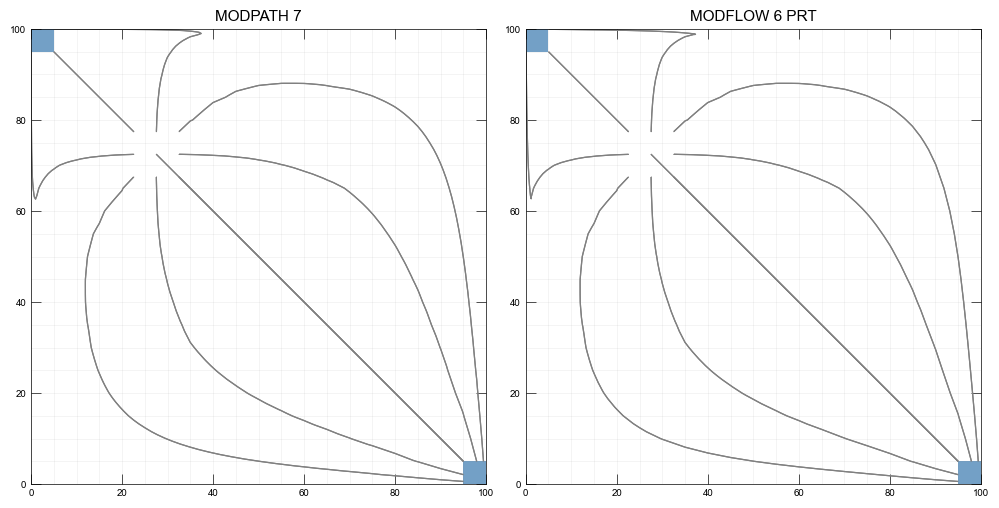

In [68]:
with flopy.plot.styles.USGSPlot():
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # mp7
    ax = axes[0]
    ax.set_aspect("equal")
    mm = flopy.plot.PlotMapView(gwf, ax=ax, layer=0)
    mm.plot_grid(alpha=0.15, lw=0.4)
    mm.plot_bc("WEL", plotAll=True, color="red", alpha=0.5)
    mm.plot_bc("CHD", plotAll=True, color="steelblue", alpha=0.5)
    mm.plot_pathline(mp7_pls, layer="all", colors=["gray"], lw=0.9)
    ax.set_title("MODPATH 7", fontsize=11)

    # prt
    ax = axes[1]
    ax.set_aspect("equal")
    mm = flopy.plot.PlotMapView(gwf, ax=ax, layer=0)
    mm.plot_grid(alpha=0.15, lw=0.4)
    mm.plot_bc("WEL", plotAll=True, color="red", alpha=0.5)
    mm.plot_bc("CHD", plotAll=True, color="steelblue", alpha=0.5)
    mm.plot_pathline(pls_prt, layer="all", colors=["gray"], lw=0.9)
    releases = pls_prt[pls_prt.ireason == 0]
    terminals = pls_prt[pls_prt.ireason == 3]
    # ax.scatter(releases.x, releases.y, s=25, c="limegreen", zorder=5, label="release")
    # ax.scatter(terminals.x, terminals.y, s=25, c="red", marker="x", zorder=5, label="terminate")
    ax.set_title("MODFLOW 6 PRT", fontsize=11)
    ax.legend(loc="upper right", fontsize=8)

    fig.tight_layout()
    plt.show()

The particles haven't moved!

Without Newton, top-layer cells are deactivated when they drain below their
bottoms. By default, particles starting at `t=0` in the top layer terminate
immediately, since at `t=0` (end of 1st stress period) the top layer is dry.

We can now turn on the DRAPE option for both MP7 and PRT, and observe that
particles drop to the water table immediately, and are tracked from there.

Next, we can turn DRAPE off, enable the Newton formulation, and compare the
behavior of PRT and MP7. 

### Summary

MODPATH 7 offers a single, fixed response to a dry cell.  PRT's
`dry_tracking_method` covers the same baseline and adds two options
that MP7 cannot replicate:

| | MODPATH 7 | PRT `stop` | PRT `drop` | PRT `stay` |
|-|:---------:|:----------:|:----------:|:----------:|
| Particle terminates in dry cell | yes | yes | — | — |
| Particle relocates to water table | — | — | yes | — |
| Particle waits for re-saturation | — | — | — | yes |
| MP7 equivalent | ✓ | ✓ | ✗ | ✗ |